In [ ]:
# !git clone https://github.com/JingyunLiang/SwinIR.git

Cloning into 'SwinIR'...


In [8]:
import cv2
import numpy as np
import torch
from SwinIR.models.network_swinir import SwinIR as net


# -------- MODEL LOADER (from define_model) --------
def load_swinir(model_path, scale=4, large_model=False, device='cuda'):

    if not large_model:
        model = net(
            upscale=scale,
            in_chans=3,
            img_size=64,
            window_size=8,
            img_range=1.,
            depths=[6,6,6,6,6,6],
            embed_dim=180,
            num_heads=[6,6,6,6,6,6],
            mlp_ratio=2,
            upsampler='nearest+conv',
            resi_connection='1conv'
        )
    else:
        model = net(
            upscale=scale,
            in_chans=3,
            img_size=64,
            window_size=8,
            img_range=1.,
            depths=[6,6,6,6,6,6,6,6,6],
            embed_dim=240,
            num_heads=[8,8,8,8,8,8,8,8,8],
            mlp_ratio=2,
            upsampler='nearest+conv',
            resi_connection='3conv'
        )

    pretrained = torch.load(model_path)

    # 🔥 FIX HERE
    if 'params_ema' in pretrained:
        model.load_state_dict(pretrained['params_ema'], strict=True)
    elif 'params' in pretrained:
        model.load_state_dict(pretrained['params'], strict=True)
    else:
        model.load_state_dict(pretrained, strict=True)

    model.eval()
    model = model.to(device)

    return model


# -------- INFERENCE FUNCTION --------
def swinir_process(image, model, scale=4, tile=None, tile_overlap=32, device='cuda'):
    """
    image: input BGR image (cv2 format)
    returns: output BGR image
    """

    window_size = 8

    # Preprocess (same as original)
    img = image.astype(np.float32) / 255.
    img = img[:, :, [2,1,0]]  # BGR → RGB
    img = np.transpose(img, (2,0,1))
    img = torch.from_numpy(img).float().unsqueeze(0).to(device)

    # Padding (IMPORTANT)
    _, _, h_old, w_old = img.size()
    h_pad = (h_old // window_size + 1) * window_size - h_old
    w_pad = (w_old // window_size + 1) * window_size - w_old

    img = torch.cat([img, torch.flip(img, [2])], 2)[:, :, :h_old + h_pad, :]
    img = torch.cat([img, torch.flip(img, [3])], 3)[:, :, :, :w_old + w_pad]

    # Inference
    with torch.no_grad():
        if tile is None:
            output = model(img)
        else:
            output = tile_inference(img, model, scale, tile, tile_overlap)

    output = output[..., :h_old*scale, :w_old*scale]

    # Postprocess
    output = output.squeeze().float().cpu().clamp_(0,1).numpy()
    output = np.transpose(output[[2,1,0], :, :], (1,2,0))  # RGB → BGR
    output = (output * 255.0).round().astype(np.uint8)

    return output


# -------- TILE INFERENCE (from original test()) --------
def tile_inference(img, model, scale, tile, tile_overlap):
    b, c, h, w = img.size()
    tile = min(tile, h, w)
    stride = tile - tile_overlap

    h_idx_list = list(range(0, h-tile, stride)) + [h-tile]
    w_idx_list = list(range(0, w-tile, stride)) + [w-tile]

    E = torch.zeros(b, c, h*scale, w*scale).type_as(img)
    W = torch.zeros_like(E)

    for h_idx in h_idx_list:
        for w_idx in w_idx_list:
            in_patch = img[..., h_idx:h_idx+tile, w_idx:w_idx+tile]
            out_patch = model(in_patch)
            mask = torch.ones_like(out_patch)

            E[..., h_idx*scale:(h_idx+tile)*scale, w_idx*scale:(w_idx+tile)*scale] += out_patch
            W[..., h_idx*scale:(h_idx+tile)*scale, w_idx*scale:(w_idx+tile)*scale] += mask

    return E / W

c:\Users\100ra\anaconda3\envs\paddle__env_clone\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\100ra\anaconda3\envs\paddle__env_clone\lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [12]:
model = load_swinir(r"D:\Automatic ANPR\Self_Code\anpr_dashboard\anpr_dashboard\core\SwinIR\003_realSR_BSRGAN_DFO_s64w8_SwinIR-M_x4_GAN.pth.zip")

img = cv2.imread(r"C:\Users\100ra\Downloads\br.jpeg")

output = swinir_process(img, model)

cv2.imwrite("output.png", output)

C:\Users\100ra\AppData\Local\Temp\ipykernel_30400\1305595120.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pretrained = torch.load(model_path)


True

In [13]:
image = cv2.imread(r"D:\Automatic ANPR\Self_Code\anpr_dashboard\anpr_dashboard\no_plate_crops_swinir\plate_crop_blur_done123.jpg")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
enhanced = clahe.apply(gray)
denoised = cv2.fastNlMeansDenoising(enhanced, None, 10, 7, 21)
kernel = np.array([[0,-1,0],
                   [-1,5,-1],
                   [0,-1,0]])

sharpened = cv2.filter2D(denoised, -1, kernel)
_, thresh = cv2.threshold(sharpened, 0, 255, 
                          cv2.THRESH_BINARY + cv2.THRESH_OTSU)

In [15]:
kernel = np.ones((2,2), np.uint8)
clean = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

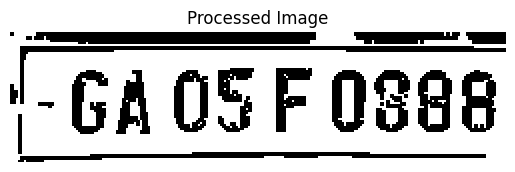

In [17]:
import matplotlib.pyplot as plt

plt.imshow(clean, cmap='gray')
plt.title("Processed Image")
plt.axis('off')
plt.show()

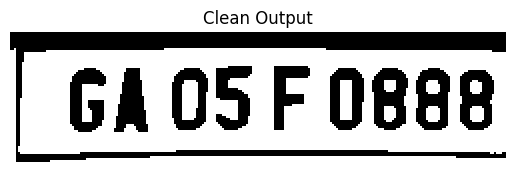

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Read image
img = cv2.imread(r"D:\Automatic ANPR\Self_Code\anpr_dashboard\anpr_dashboard\no_plate_crops_swinir\plate_crop_blur_done123.jpg")

# 2. Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 3. Light blur (remove noise, not destroy edges)
blur = cv2.GaussianBlur(gray, (3,3), 0)

# 4. Otsu threshold (automatic clean binary)
_, thresh = cv2.threshold(blur, 0, 255,
                          cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 5. Optional: invert (if text becomes white)
# thresh = 255 - thresh

# 6. Show result
plt.imshow(thresh, cmap='gray')
plt.title("Clean Output")
plt.axis('off')
plt.show()